In [2]:
##########################################
# A SCRIPT TO LOAD NCSS GFS ANALYSIS AND
# FOR BASIC MAP ANALYSIS
##########################################

import warnings
warnings.filterwarnings("ignore")

# IMPORTS
import time as comp_time
import sys
from siphon.catalog import TDSCatalog
from siphon.ncss import NCSS
from datetime import datetime, timedelta
from xarray.backends import NetCDF4DataStore
import xarray as xr
import numpy as np # Added for consistency in calling np.arange if needed outside this function

def gfs_forecast(center_lat=37.86, center_lon=-98.61, box_size=20, forecast_hours=[6, 12, 18, 24, 36, 48, 60, 72]):
    st = comp_time.time()
    
    print('ACCESSING GFS DATA...')
    
    # define dataset URL
    url = 'https://thredds.ucar.edu/thredds/catalog/grib/NCEP/GFS/Global_0p25deg/latest.xml'
    
    try:
        cat = TDSCatalog(url)
    except Exception as e:
        sys.exit(f"NCSS URL FAILED -- GFS data may not be available at this time. Error: {e}")
    
    latest_ds = list(cat.datasets.values())[0]
    ncss = NCSS(latest_ds.access_urls['NetcdfSubset'])
    
    # Find analysis time
    start_time = ncss.metadata.time_span['begin']
    base_time = datetime.strptime(start_time, '%Y-%m-%dT%H:%M:%SZ')
    
    # Define the datetime objects for all desired forecast hours
    query_times = [base_time + timedelta(hours=fh) for fh in forecast_hours]

    query = ncss.query()

    # --- FIX APPLIED HERE: Removed the invalid .subset_nearest() method ---
    # Request a time range from the earliest to the latest forecast hour
    query.time_range(query_times[0], query_times[-1])
    
    query.accept('netcdf4')
    
    # Subset variables
    query.variables(
        'MSLP_Eta_model_reduction_msl',
        'Pressure_surface',
        'Geopotential_height_isobaric',
        'Temperature_isobaric',
        'Relative_humidity_isobaric',
        'Temperature_height_above_ground',
        'Relative_humidity_height_above_ground',
        'u-component_of_wind_height_above_ground', 'v-component_of_wind_height_above_ground',
        'u-component_of_wind_isobaric', 'v-component_of_wind_isobaric',
        "Categorical_Rain_surface","Categorical_Freezing_Rain_surface",
        "Categorical_Ice_Pellets_surface", "Categorical_Snow_surface", 
        "Composite_reflectivity_entire_atmosphere"
    ).add_lonlat()
        
    # Subset by lat-lon domain (using your current wide domain)
    query.lonlat_box(north=58.415, west=-139.970, east=-57.269, south=16.209)
    
    # Fetch data (single request for all times)
    ncss_data = ncss.get_data(query)

    # Open the full 4D dataset (Time, Level, Lat, Lon)
    raw_data_full = xr.open_dataset(NetCDF4DataStore(ncss_data)).metpy.parse_cf()
        
    # Iterate through the full dataset to extract individual forecast hours using Xarray's nearest selection
    all_forecasts = {}
    
    print('Data received. Processing individual forecast hours...')

    for fh in forecast_hours:
        time_to_select = base_time + timedelta(hours=fh) 
        
        # Use Xarray's .sel with method='nearest' to handle any mismatch
        try:
            forecast_slice = raw_data_full.sel(time=time_to_select, method='nearest')
        except:
            try:
                forecast_slice = raw_data_full.sel(time1=time_to_select, method='nearest')
            except:
                forecast_slice = raw_data_full.sel(time2=time_to_select, method='nearest')
                pass
            pass
        
        all_forecasts[fh] = forecast_slice
        print(f'Processed GFS forecast for +{fh} hours: {time_to_select.strftime("%Y-%m-%d %H:%M:%SZ")}')

    elapsed_time = comp_time.time() - st
    print('ALL FORECASTS LOADED. Time elapsed:', comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time)))
    
    return all_forecasts

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


############
SCRIPT RUNNING
############


Text(0.915, -0.01, ' ')

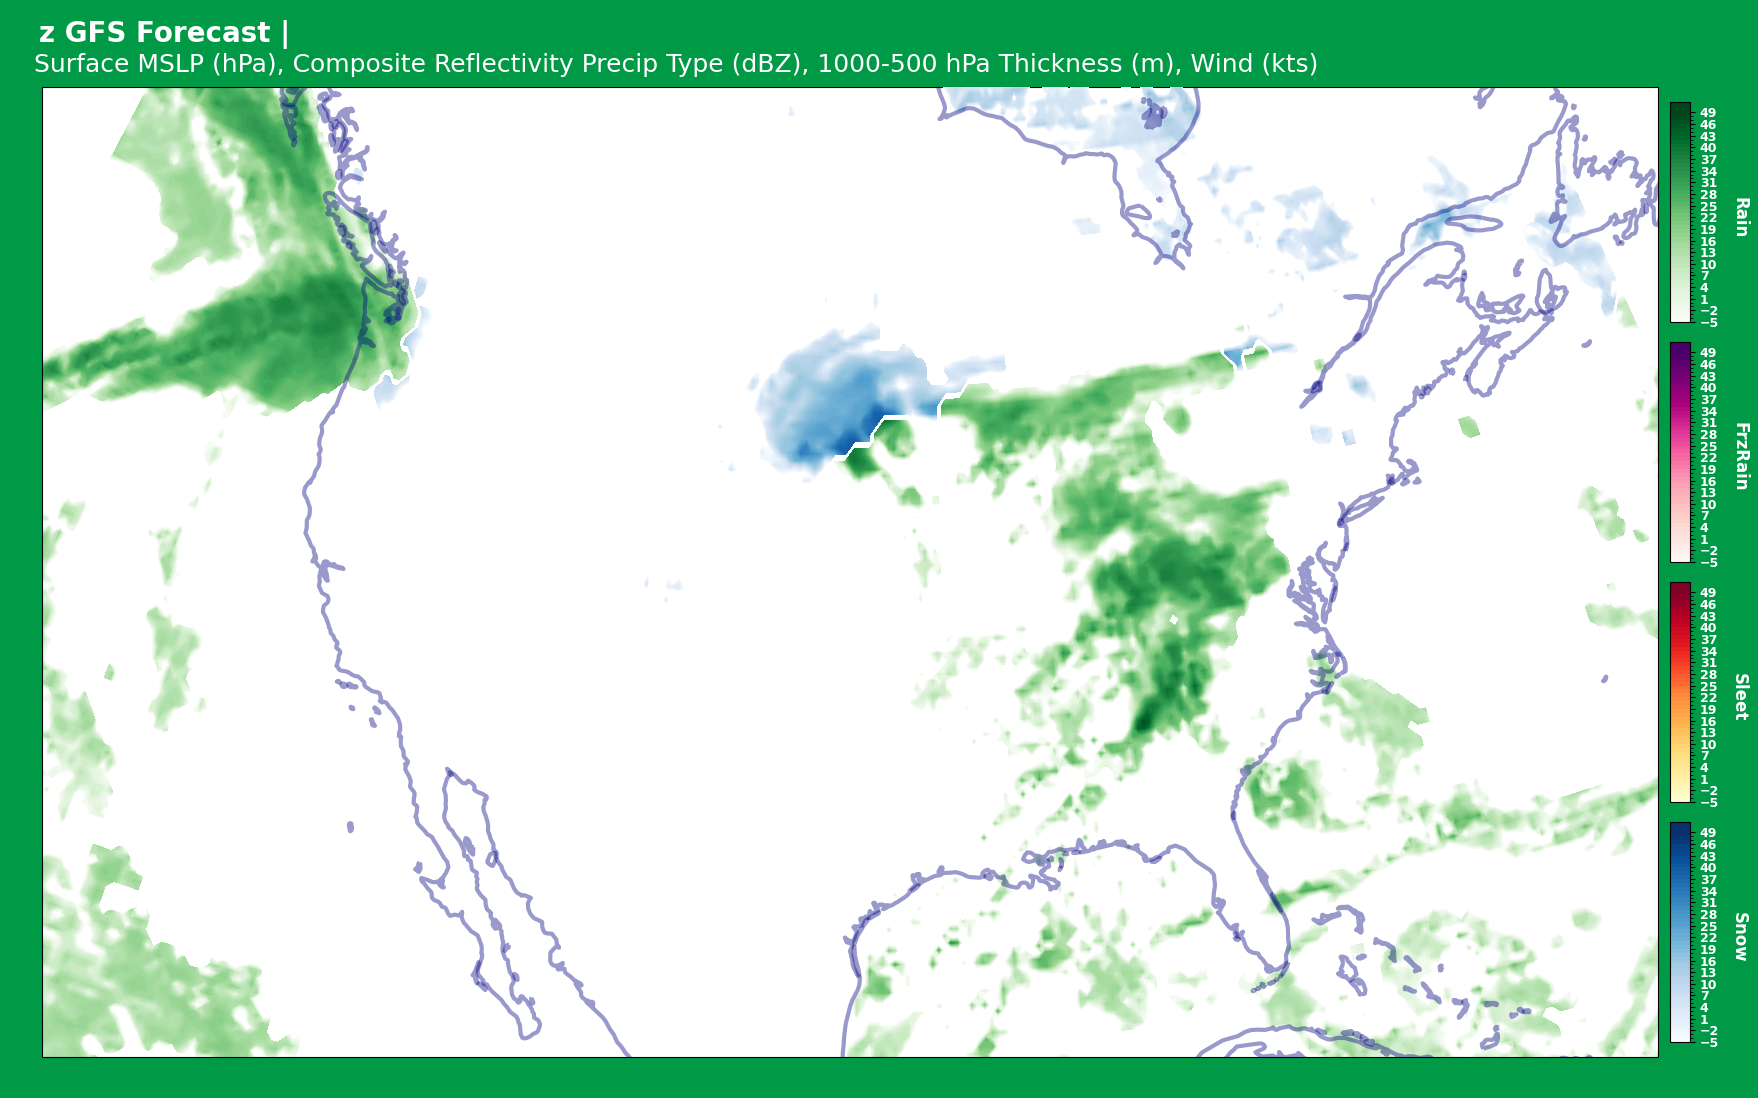

In [13]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import interpolate_to_isosurface
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np
import sys
import os
import xarray as xr

def build_map(extent=[-122, -73, 21, 56], projection=ccrs.LambertConformal(), style='light'):
    fig = plt.figure(figsize=(20, 10))
    fig.set_facecolor('#009946')
    ax = plt.axes(projection=projection)

    ax.set_extent(extent)
    ax.set_box_aspect(0.6)

    if style == 'light':
        color = 'gray'
        alpha = 0.5
    else:
        color = 'black'
        alpha = 0.8

    #ax.add_feature(cfeature.STATES, edgecolor='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=10)
    #ax.add_feature(cfeature.LAND, facecolor=color, alpha=alpha, zorder=1)
    #ax.add_feature(cfeature.OCEAN, facecolor=color, alpha=alpha + 0.2, zorder=0)
    ax.add_feature(cfeature.COASTLINE, color='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=11)

    #from cartopy.io import img_tiles
    #satellite = img_tiles.GoogleTiles(style='satellite')
    #ax.add_image(satellite, 4)

    plt.tight_layout()

    return fig, ax
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################




#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################

# set up rap retrieval 
center_lat = 46.841203
center_lon = -98.777673
box_size   = 35
west = center_lon  - box_size
east = center_lon  + box_size
south = center_lat - box_size
north = center_lat + box_size

# pull rap data
#datas = gfs_forecast(box_size=box_size, forecast_hours=[33])

for fh, raw_data in datas.items():

    fh = str(fh).zfill(3)

    # LATS & LONS
    lats = raw_data.variables['latitude'][:]
    lons = raw_data.variables['longitude'][:]


    import numpy as np
    from scipy import ndimage
    from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
    reft_sfc = ndimage.gaussian_filter(raw_data.variables['Composite_reflectivity_entire_atmosphere'], 0.1)
    rn_sfc = ndimage.gaussian_filter(raw_data.variables['Categorical_Rain_surface'], 0.75)
    sn_sfc = ndimage.gaussian_filter(raw_data.variables['Categorical_Snow_surface'], 0.75)
    zr_sfc = ndimage.gaussian_filter(raw_data.variables['Categorical_Freezing_Rain_surface'], 0.75)
    ip_sfc = ndimage.gaussian_filter(raw_data.variables['Categorical_Ice_Pellets_surface'], 0.75)



    ptype = np.zeros_like(rn_sfc)
    ptype = np.where(sn_sfc >= 0.01, 4, ptype)
    ptype = np.where(ip_sfc >= 0.01, 3, ptype)
    ptype = np.where(zr_sfc >= 0.01, 2, ptype)
    ptype = np.where(rn_sfc >= 0.01, 1, ptype)

    # prepare masking, cmaps, levels, norm
    levels = np.arange(-5, 50, 1)
    norm = BoundaryNorm(levels, 256)
    ptype_data_2d = {
        'Rain': (1, np.where(ptype == 1, reft_sfc, np.nan), 'Greens'),
        'FrzRain': (2, np.where(ptype == 2, reft_sfc, np.nan), 'RdPu'),
        'Sleet': (3, np.where(ptype == 3, reft_sfc, np.nan), 'YlOrRd'),
        'Snow': (4, np.where(ptype == 4, reft_sfc, np.nan), 'Blues'),
    }
        
    fig, ax = build_map()
    # store contourf mappable objs in a dict for cbars
    cf_mappables = {} 
    for name, (value, mask, cmap) in ptype_data_2d.items():
        cf = ax.contourf(lons, lats, mask, levels=levels,cmap=cmap,norm=norm,
            transform=ccrs.PlateCarree(),extend='max', zorder=value)
        cf_mappables[name] = cf



cbar_x_start = 0.91 
cbar_width = 0.01 
cbar_height = 0.22
cbar_spacing = 0.02 
cbar_y_start_top = 0.75

ptype_order = ['Rain', 'FrzRain', 'Sleet', 'Snow'] 

for i, name in enumerate(ptype_order):
    cbar_y_start = cbar_y_start_top - (i * (cbar_height + cbar_spacing))
    cax = fig.add_axes([cbar_x_start, cbar_y_start, cbar_width, cbar_height])
    cbar = fig.colorbar(cf_mappables[name],cax=cax,orientation='vertical',ticks=levels[::3],extendrect=True)
    cax.text( 3.0, 0.5, f'{name}',ha='left',va='center',rotation=270,color='white',fontsize=12,fontweight='bold',transform=cax.transAxes)
    cbar.ax.tick_params(axis='y', labelcolor='white') 
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')
        t.set_fontsize(9)
    cbar.ax.set_facecolor('black')
    
# plot title, add one to the left with model name and data names, add another to the right with time info
plt.figtext(0.08, 1.03, f'   z GFS Forecast | ', weight='bold', ha='left', fontsize=20, color='white')
plt.figtext(0.08, 1.00, f'   Surface MSLP (hPa), Composite Reflectivity Precip Type (dBZ), 1000-500 hPa Thickness (m), Wind (kts)', ha='left', fontsize=18, color='white')
plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
plt.figtext(0.915, -0.01, f' ', ha='left', fontsize=20)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


############
SCRIPT RUNNING
############


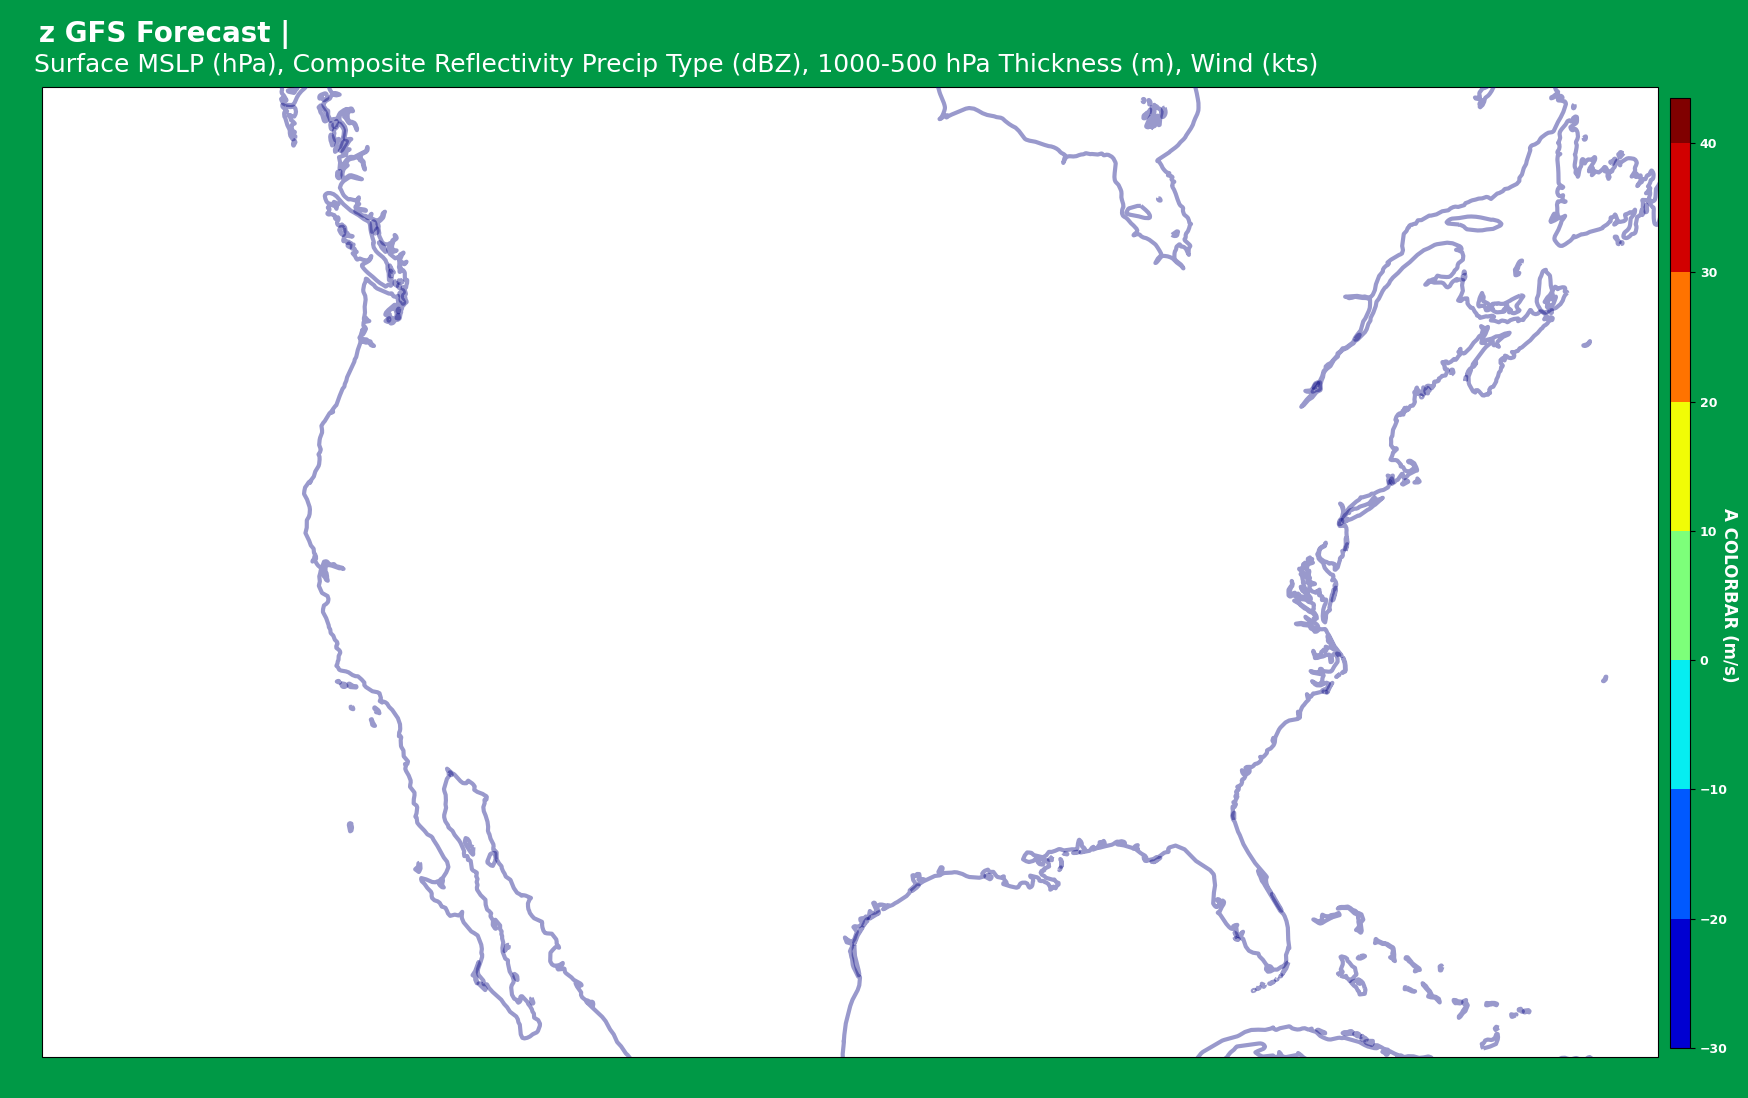

In [56]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import interpolate_to_isosurface
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np
import sys
import os
import xarray as xr

def build_map(extent=[-122, -73, 21, 56], projection=ccrs.LambertConformal(), style='light'):
    fig = plt.figure(figsize=(20, 10))
    fig.set_facecolor('#009946')
    ax = plt.axes(projection=projection)

    ax.set_extent(extent)
    ax.set_box_aspect(0.6)

    if style == 'light':
        color = 'gray'
        alpha = 0.5
    else:
        color = 'black'
        alpha = 0.8

    #ax.add_feature(cfeature.STATES, edgecolor='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=10)
    #ax.add_feature(cfeature.LAND, facecolor=color, alpha=alpha, zorder=1)
    #ax.add_feature(cfeature.OCEAN, facecolor=color, alpha=alpha + 0.2, zorder=0)
    ax.add_feature(cfeature.COASTLINE, color='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=11)

    #from cartopy.io import img_tiles
    #satellite = img_tiles.GoogleTiles(style='satellite')
    #ax.add_image(satellite, 4)

    plt.tight_layout()

    return fig, ax
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################




#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################

# set up rap retrieval 
center_lat = 46.841203
center_lon = -98.777673
box_size   = 35
west = center_lon  - box_size
east = center_lon  + box_size
south = center_lat - box_size
north = center_lat + box_size

# pull rap data
#datas = gfs_forecast(box_size=box_size, forecast_hours=[33])

for fh, raw_data in datas.items():

    fh = str(fh).zfill(3)

    # LATS & LONS
    lats = raw_data.variables['latitude'][:]
    lons = raw_data.variables['longitude'][:]


    # import numpy as np
    # from scipy import ndimage
    # from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm
    # reft_sfc = ndimage.gaussian_filter(raw_data.variables['Composite_reflectivity_entire_atmosphere'], 0.1)

    fig, ax = build_map()

    # contourf = ax.contourf(lons, lats, reft_sfc, cmap='jet',
    #     transform=ccrs.PlateCarree(),extend='max', zorder=value)
    
    # colorbar for filled contour
    # cbar = plt.colorbar(contourf, aspect=40, fraction=0.05, ax=ax, orientation='vertical', pad=0.01, extendrect=True)
    # cbar.set_label('Temperature (C)',  fontsize=12, color='white', fontweight='bold')
    # cbar.ax.tick_params(axis='y', labelcolor='white')
    # for t in cbar.ax.get_yticklabels():
    #     t.set_fontweight('bold')
    #     t.set_fontsize(9)
    # cbar.ax.set_facecolor('black')



    cax = fig.add_axes([0.91, 0.024, 0.01, 0.95])
    cbar = fig.colorbar(contourf, cax=cax, orientation='vertical', extendrect=True)
    cax.text(2.5, 0.5, f'A COLORBAR (m/s)',ha='left',va='center',rotation=270,color='white',fontsize=12,fontweight='bold',transform=cax.transAxes)
    cbar.ax.tick_params(axis='y', labelcolor='white') 
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')
        t.set_fontsize(9)
    cbar.ax.set_facecolor('black')
    
    # plot title, add one to the left with model name and data names, add another to the right with time info
    plt.figtext(0.08, 1.03, f'   z GFS Forecast | ', weight='bold', ha='left', fontsize=20, color='white')
    plt.figtext(0.08, 1.00, f'   Surface MSLP (hPa), Composite Reflectivity Precip Type (dBZ), 1000-500 hPa Thickness (m), Wind (kts)', ha='left', fontsize=18, color='white')
    plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
    plt.figtext(0.915, -0.01, f' ', ha='left', fontsize=20)


In [30]:
# use metpy to compute theta & add it into the `rap-data` DataSet
raw_data['theta'] = mpcalc.potential_temperature(raw_data['isobaric'],raw_data['Temperature_isobaric'])

# use metpy to compute latitude / longitude grid deltas (dx, dy) for PV calculation
dx, dy = mpcalc.lat_lon_grid_deltas(raw_data['longitude'].values, raw_data['latitude'].values)

raw_data['pv'] = mpcalc.potential_vorticity_baroclinic(raw_data['theta'],
                                                        raw_data['isobaric'],
                                                        u=raw_data['u-component_of_wind_isobaric'],
                                                        v=raw_data['v-component_of_wind_isobaric'],
                                                        dx=dx[None, :, :], dy=dy[None, :, :],
                                                        latitude=raw_data['latitude'])

In [33]:
interpolate_to_isosurface(raw_data['pv'][:,:,:].values, raw_data['u-component_of_wind_isobaric'][:,:,:].values, 2*1e-6, bottom_up_search=True)

array([[24.18775798, 24.429617  , 24.67278995, ...,  2.00118388,
         3.0685151 ,  4.29999166],
       [22.08246639, 22.41888297, 16.04573847, ...,  3.62270549,
         4.34880875,  5.02436426],
       [20.38192091, 20.92839738, 20.98224776, ...,  6.55097508,
        11.96338643,  7.78277655],
       ...,
       [34.6904252 , 36.38873473, 33.56932041, ...,  6.46590546,
         7.48410466, 35.06365863],
       [34.72838533, 33.24369698, 33.2679494 , ..., 27.48610785,
        28.29438801, 27.83282069],
       [32.9543588 , 34.25713299, 35.11997416, ..., 36.4186341 ,
         6.80007542, 40.07578602]])

In [ ]:
new cell 




In [4]:
import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import interpolate_to_isosurface
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import numpy as np
import sys
import os
import xarray as xr

def build_map(extent=[-122, -73, 21, 56], projection=ccrs.LambertConformal(), style='light'):
    fig = plt.figure(figsize=(20, 12))
    fig.set_facecolor('#009946')
    ax = plt.axes(projection=projection)

    ax.set_extent(extent)
    ax.set_box_aspect(0.7)

    if style == 'light':
        color = 'gray'
        alpha = 0.5
    else:
        color = 'black'
        alpha = 0.8

    ax.add_feature(cfeature.STATES, edgecolor='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=10)
    ax.add_feature(cfeature.LAND, facecolor=color, alpha=alpha, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor=color, alpha=alpha + 0.2, zorder=0)
    ax.add_feature(cfeature.COASTLINE, color='navy', alpha=0.4, linestyle='-', linewidth=3, zorder=11)

    plt.tight_layout()

    return fig, ax
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################


In [ ]:
#############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #################################
    # BUILD 300 HPA MAP
    #################################
    fig, ax = build_map()

    # slice data
    plev300 = np.where(pres_levs == 300)[0][0]
    ghgt_300 = ghgt_iso[plev300]
    uwnd_300 = uwnd_iso[plev300]
    vwnd_300 = vwnd_iso[plev300]
    wdsp_300 = np.sqrt(uwnd_300**2 + vwnd_300**2)

    # plot 300 hpa heights
    contour = ax.contour(lons, lats, ghgt_300, np.arange(0, 12000, 120),
                    colors='black', linewidths=3.0, linestyles='-',
                    transform=ccrs.PlateCarree(), zorder=11)
    plt.clabel(contour, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
            rightside_up=True, use_clabeltext=True)

    # plot 300 hpa wind speed
    contourf = ax.contourf(lons, lats, wdsp_300, np.arange(50, 160, 5), extend='both',
                    cmap=wdsp_cmap, alpha=0.7, transform=ccrs.PlateCarree(), zorder=4)

    # plot 300 hpa wind barbs
    every = 20
    barbs = ax.barbs(lons.values[0::every, 0::every], lats.values[0::every, 0::every],
                    uwnd_300[0::every, 0::every], vwnd_300[0::every, 0::every],
                    length=6.5, alpha=0.7, transform=ccrs.PlateCarree(), zorder=12)

    # plot title, add one to the left with model name and data names, add another to the right with time info
    plt.figtext(0.08, 1.03, f'   GFS F{fh} 300 hPa Analysis | {valid_date[0:10]} {valid_date[11:-13]}z', weight='bold', ha='left', fontsize=20, color='white')
    plt.figtext(0.08, 1.00, f'   Heights (m), Wind (kt)', ha='left', fontsize=18, color='white')
    plt.figtext(0.915, 1.04, f' ', ha='left', fontsize=20)
    # colorbar for filled contour
    cbar = plt.colorbar(contourf, aspect=70, fraction=0.02, ax=ax, orientation='horizontal', pad=-0.01, extendrect=True)
    cbar.set_label('Wind Speed (kts)', fontsize=15, color='white', fontweight='bold')
    cbar.ax.tick_params(labelcolor='white')
    for t in cbar.ax.get_xticklabels():
        t.set_fontweight('bold')

    # add UND logo
    from PIL import Image
    img = Image.open('utils/images/und-logo.png')
    #                  side-side  up-down  size   size
    imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
    plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
    imgax.imshow(img)
    imgax.axis('off')

    plt.savefig("staged_figures/conus_rap_analysis/rap_300_flow.png", bbox_inches="tight")

    print("    FINISHED 300HPA FLOW MAP")
    #############################################################################################################################################################################
    #############################################################################################################################################################################
    #############################################################################################################################################################################


In [21]:
import scipy.ndimage as ndimage
import metpy.calc as mpcalc
from metpy.units import units

for fh, raw_data in datas.items():

    # set up rap retrieval 
    center_lat = 46.841203
    center_lon = -98.777673
    box_size   = 35
    west = center_lon  - box_size
    east = center_lon  + box_size
    south = center_lat - box_size
    north = center_lat + box_size

    # LATS & LONS
    lats = raw_data.variables['latitude'][:]
    lons = raw_data.variables['longitude'][:]

    # PRES LEVS
    pres_levs = raw_data['isobaric'][:]
    pres_levs = pres_levs / 100

    # DATE INFO
    try:
        data_date = raw_data['time'].values[0]
    except:
        try:
            for i in time:
                data_date = raw_data[f'time{i}'].values[0]
        except:
            pass
        pass

    valid_date = f'{data_date}'


    # BASIC DATA EXTRACTION
    sigma = 1.5
    ghgt_iso = ndimage.gaussian_filter(raw_data.variables['Geopotential_height_isobaric'][0], sigma=sigma)
    temp_iso = ndimage.gaussian_filter(raw_data.variables['Temperature_isobaric'][0], sigma=sigma) - 273.15
    uwnd_iso = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384
    vwnd_iso = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_isobaric'][0], sigma=sigma) * 1.94384

    pres_sfc = ndimage.gaussian_filter(raw_data.variables['MSLP_Eta_model_reduction_msl'][0], sigma=sigma) / 100
    temp_sfc = ndimage.gaussian_filter(raw_data.variables['Temperature_height_above_ground'][0], sigma=sigma) - 273.15
    uwnd_sfc = ndimage.gaussian_filter(raw_data.variables['u-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    vwnd_sfc = ndimage.gaussian_filter(raw_data.variables['v-component_of_wind_height_above_ground'][0], sigma=sigma) * 1.94384
    relh_sfc = ndimage.gaussian_filter(raw_data.variables['Relative_humidity_height_above_ground'][0], sigma=sigma)
    dwpt_sfc = mpcalc.dewpoint_from_relative_humidity(temp_sfc*units.degC, relh_sfc*units.percent)


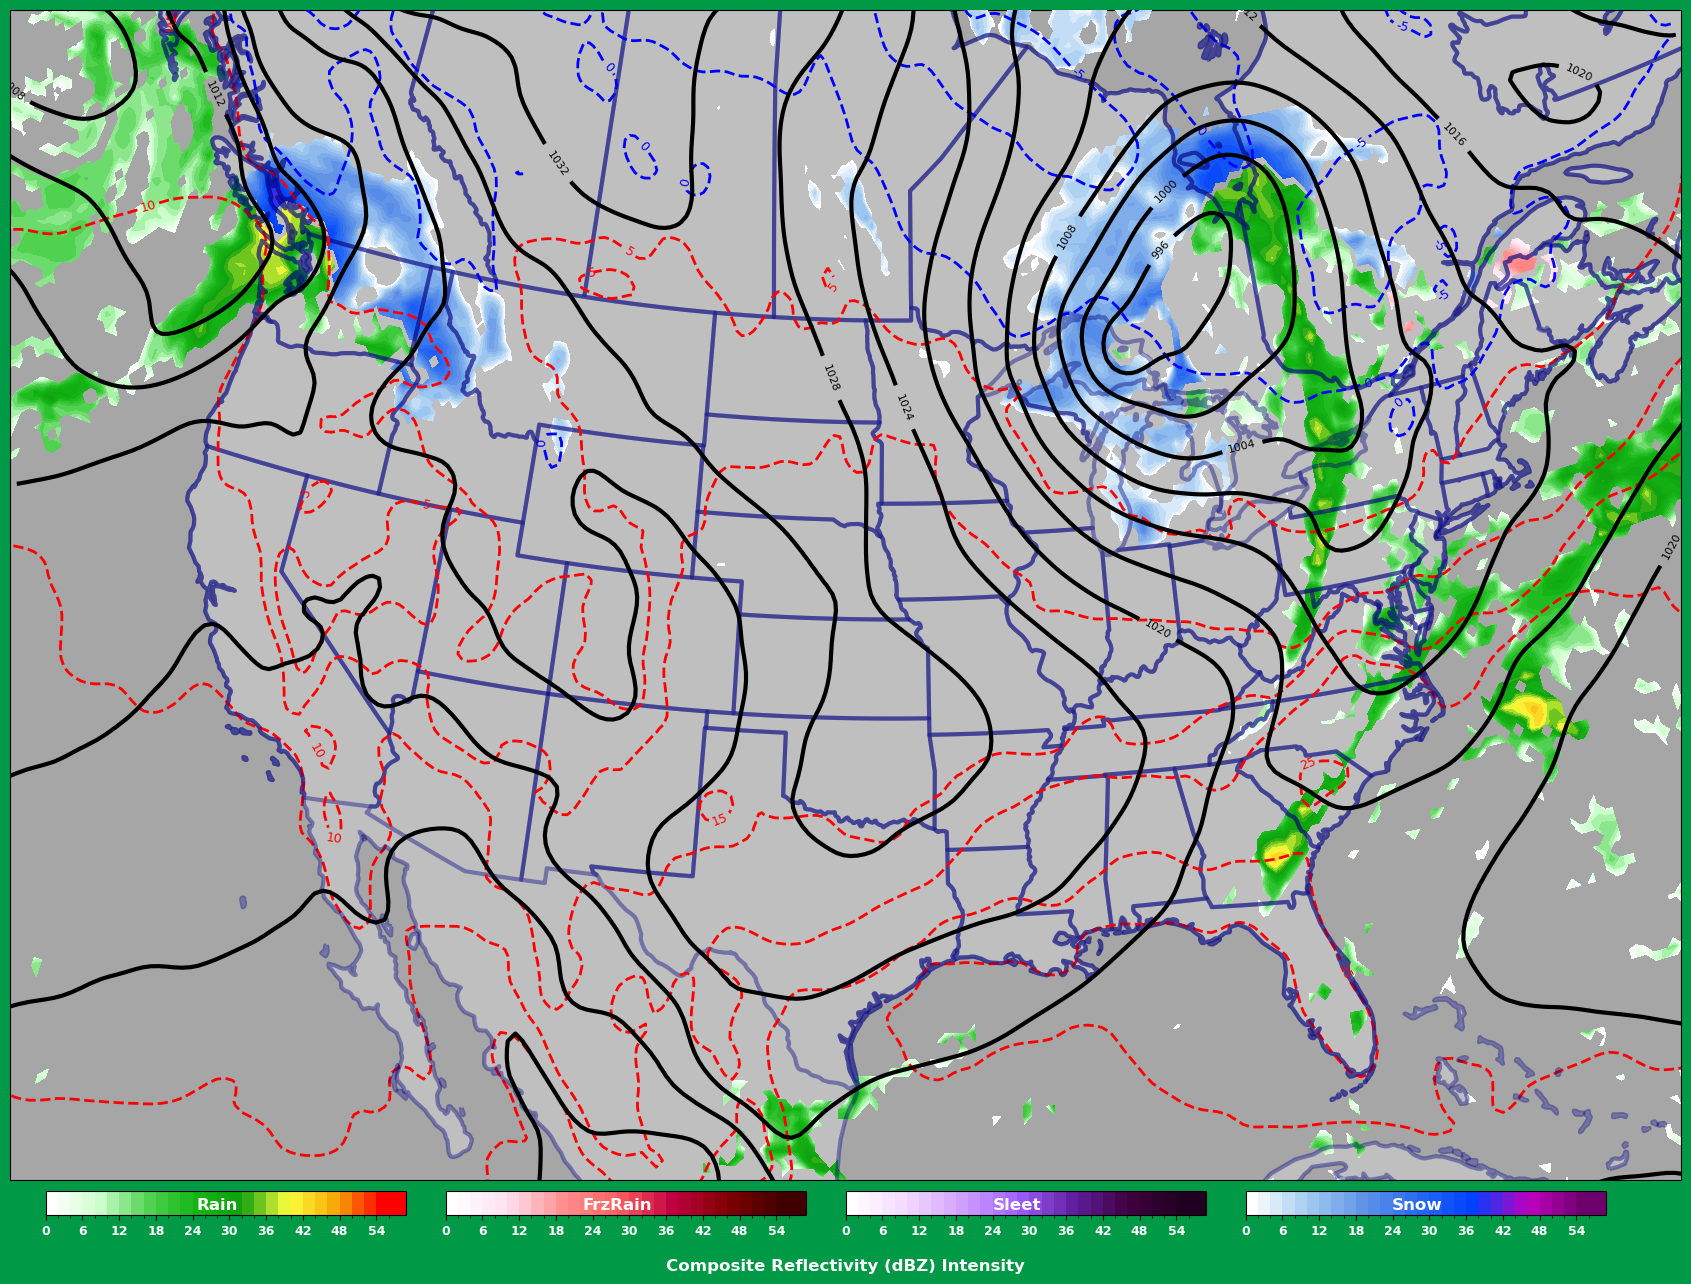

In [ ]:
#datas = gfs_forecast(box_size=box_size, forecast_hours=[108])

raw_data = datas[108]

from matplotlib.patches import Patch
# --- 1. COORDINATE AND DIMENSION SETUP ---
lats = raw_data.variables['latitude'][:]
lons = raw_data.variables['longitude'][:]

pres_sfc = ndimage.gaussian_filter(raw_data.variables['MSLP_Eta_model_reduction_msl'][0], 2)
reflectivity_field = ndimage.gaussian_filter(raw_data.variables['Composite_reflectivity_entire_atmosphere'][0], 0.5)


sigma_cat = 0
threshold = 0.5
def process_cat_field(var_name):
    raw_field = raw_data.variables[var_name][0]
    smoothed = ndimage.gaussian_filter(raw_field, sigma=sigma_cat)
    return raw_field

cat_rn = process_cat_field('Categorical_Rain_surface')
cat_zr = process_cat_field('Categorical_Freezing_Rain_surface')
cat_ip = process_cat_field('Categorical_Ice_Pellets_surface')
cat_sn = process_cat_field('Categorical_Snow_surface')


ptype = np.zeros_like(cat_rn)
ptype = np.where(cat_sn == 1, 4, ptype) 
ptype = np.where(cat_ip == 1, 3, ptype)
ptype = np.where(cat_zr == 1, 2, ptype)
ptype = np.where(cat_rn == 1, 1, ptype)



# Standard Reflectivity (dBZ) Levels for visualization
levels = np.arange(0, 57, 2)
norm = BoundaryNorm(levels, 256)

cmaps = {
    'Rain': LinearSegmentedColormap.from_list("rain", 
                ["#FFFFFF", "#CCFFCC", "#54D354", "#15B615", "#0EA00E", "#FFFF3C", "#F8A705", "#FF0000"]), 
                # White (0 dBZ), light green (~5-15 dBZ), mid green (~15-25 dBZ), 
                # dark green (~25-35 dBZ), darker green (~35-45 dBZ), 
                # -> Yellow (~45-55 dBZ) -> Orange (~55-65 dBZ) -> Red (>65 dBZ)

    'Snow': LinearSegmentedColormap.from_list("snow", 
              ["#FFFFFF", "#A3CBF0", "#6194E7", "#276AF0", "#0040FF", "#C000C0", "#6E006E"]), 
              # White (low), light blue, mid blue, dark blue, very dark blue (mid-range intense snow)
              # -> Magenta (stronger snow/heavy accumulation) -> Dark Purple (very heavy/blizzard)

    'FrzRain': LinearSegmentedColormap.from_list("frzr", 
              ["#FFFFFF", "#FFE0F0", "#FF9090", "#FF6060", "#C00040", "#800000", "#400000"]), 
              # White (low), light pink/red, mid red, strong red, deep red (mid-range freezing rain)
              # -> Dark Red/Maroon (intense freezing rain) -> Very Dark Red (severe icing)

    'Sleet': LinearSegmentedColormap.from_list("sleet", 
              ["#FFFFFF", "#F3D8FF", "#D0A0FF", "#A060FF", "#6020A0", "#400040", "#200020"]), 
              # White (low), light lavender, mid purple, strong purple, deep purple (mid-range sleet)
              # -> Dark Purple -> Very Dark Purple (intense sleet/ice pellet accumulation)
}

# ----- Masks (Using reflectivity_field_2d for intensity) -----
ptype_data_2d = {
    'Rain': (1, np.where(ptype == 1, reflectivity_field, np.nan), cmaps['Rain']),
    'FrzRain': (2, np.where(ptype == 2, reflectivity_field, np.nan), cmaps['FrzRain']),
    'Sleet': (3, np.where(ptype == 3, reflectivity_field, np.nan), cmaps['Sleet']),
    'Snow': (4, np.where(ptype == 4, reflectivity_field, np.nan), cmaps['Snow']),
}


# --- 6. Plotting ---
fig, ax = build_map()

### A. Continuous Colorbar for Reflectivity (dBZ) ###
# We use the first contourf object for the numerical scaling (levels/norm are identical for all)
cf_mappables = {} # Store mappables by name for colorbars

for name, (value, mask, cmap) in ptype_data_2d.items():
    cf = ax.contourf(
        lons, lats, mask, 
        levels=levels,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        extend='max',
        zorder=value # Ensures higher priority ptypes (Snow=4) are drawn on top if they overlap
    )
    # Store the contourf object for the colorbar mapping
    cf_mappables[name] = cf

# plot mslp
cs = ax.contour(lons, lats, pres_sfc/100, np.arange(904, 1054, 4), colors='black',
                linewidths=3.0, linestyles='-',
                transform=ccrs.PlateCarree(), zorder=11)
plt.clabel(cs, fontsize=8, inline=1, inline_spacing=10, fmt='%i',
        rightside_up=True, use_clabeltext=True)


# --- 7. Create Four Horizontal Colorbars with Custom Settings ---

# Define the starting Y position and height for all colorbars
cbar_y_start = -0.017
cbar_height = 0.02

# Define the width and spacing for the four horizontal colorbars
cbar_width = 0.18 
cbar_spacing = 0.02

# The order we want them in
ptype_order = ['Rain', 'FrzRain', 'Sleet', 'Snow'] 

for i, name in enumerate(ptype_order):
    cbar_x_start = 0.1 + (i * (cbar_width + cbar_spacing))
    
    # 7.1 Create a new axes for the colorbar
    cax = fig.add_axes([cbar_x_start, cbar_y_start, cbar_width, cbar_height])
    
    # 7.2 Create the colorbar using the custom settings
    cbar = fig.colorbar(
        cf_mappables[name],
        cax=cax,
        orientation='horizontal',
        ticks=levels[::3],
        extendrect=True # Apply extendrect=True
    )
    
    # *** CHANGE: Use cax.text to place the label INSIDE the axes ***
    # x=0.5 (center of the bar), y=1.5 (slightly above the bar) in axes coordinates
    cax.text(0.5, 0.4, f'{name}',
            ha='center',
            va='center',
            color='white',
            fontsize=12,
            fontweight='bold',
            transform=cax.transAxes) # Use transAxes for relative positioning

        # Remove the default title area which is no longer needed
        # (Though cax.set_title was already replaced by cax.text)
        
    # Set tick parameters (color and font weight)
    cbar.ax.tick_params(axis='x', labelcolor='white')
    
    for t in cbar.ax.get_xticklabels():
        t.set_fontweight('bold')
        t.set_fontsize(9) 
    
    cbar.ax.set_facecolor('black')


In [128]:
from PIL import Image, ImageDraw, ImageFont
import glob
 
# Create the frames
frames = []
imgs = glob.glob('../staged_figures/conus_gfs_forecasts/gfs_sfc_ptype*.png')
for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)
    
print(imgs)
    
#Save into a GIF file that loops forever
frames[0].save('gfs_sfc_ptype_loop.gif', format='GIF',
               append_images=frames[1:],
               save_all=True,
               duration=900, loop=5)

['../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F006.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F012.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F018.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F024.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F030.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F036.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F042.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F048.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F054.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F060.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F066.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F072.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F075.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F078.png', '../staged_figures/conus_gfs_forecasts\\gfs_sfc_ptype_F084.png', '../staged_figures/conus

In [126]:
[int(hr) for hr in np.arange(6, 157, 6)]

[6,
 12,
 18,
 24,
 30,
 36,
 42,
 48,
 54,
 60,
 66,
 72,
 78,
 84,
 90,
 96,
 102,
 108,
 114,
 120,
 126,
 132,
 138,
 144,
 150,
 156]

In [96]:
raw_data.variables["Categorical_Rain_surface"][0]

<xarray.Variable (latitude: 170, longitude: 332)> Size: 226kB
[56440 values with dtype=float32]
Attributes:
    long_name:                       Categorical Rain @ Ground or water surface
    units:                           Code table 4.222
    Grib_Variable_Id:                VAR_0-1-192_L1
    Grib2_Parameter:                 [  0   1 192]
    Grib2_Parameter_Discipline:      Meteorological products
    Grib2_Parameter_Category:        Moisture
    Grib2_Parameter_Name:            Categorical Rain
    Grib2_Level_Type:                1
    Grib2_Level_Desc:                Ground or water surface
    Grib2_Generating_Process_Type:   Forecast
    Grib2_Statistical_Process_Type:  UnknownStatType--1
    grid_mapping:                    LatLon_721X1440-0p13S-180p00E

############
SCRIPT RUNNING
############
    FINISHED ACE FIGURE
############
SCRIPT FINISHED: time: 00:00:01
############


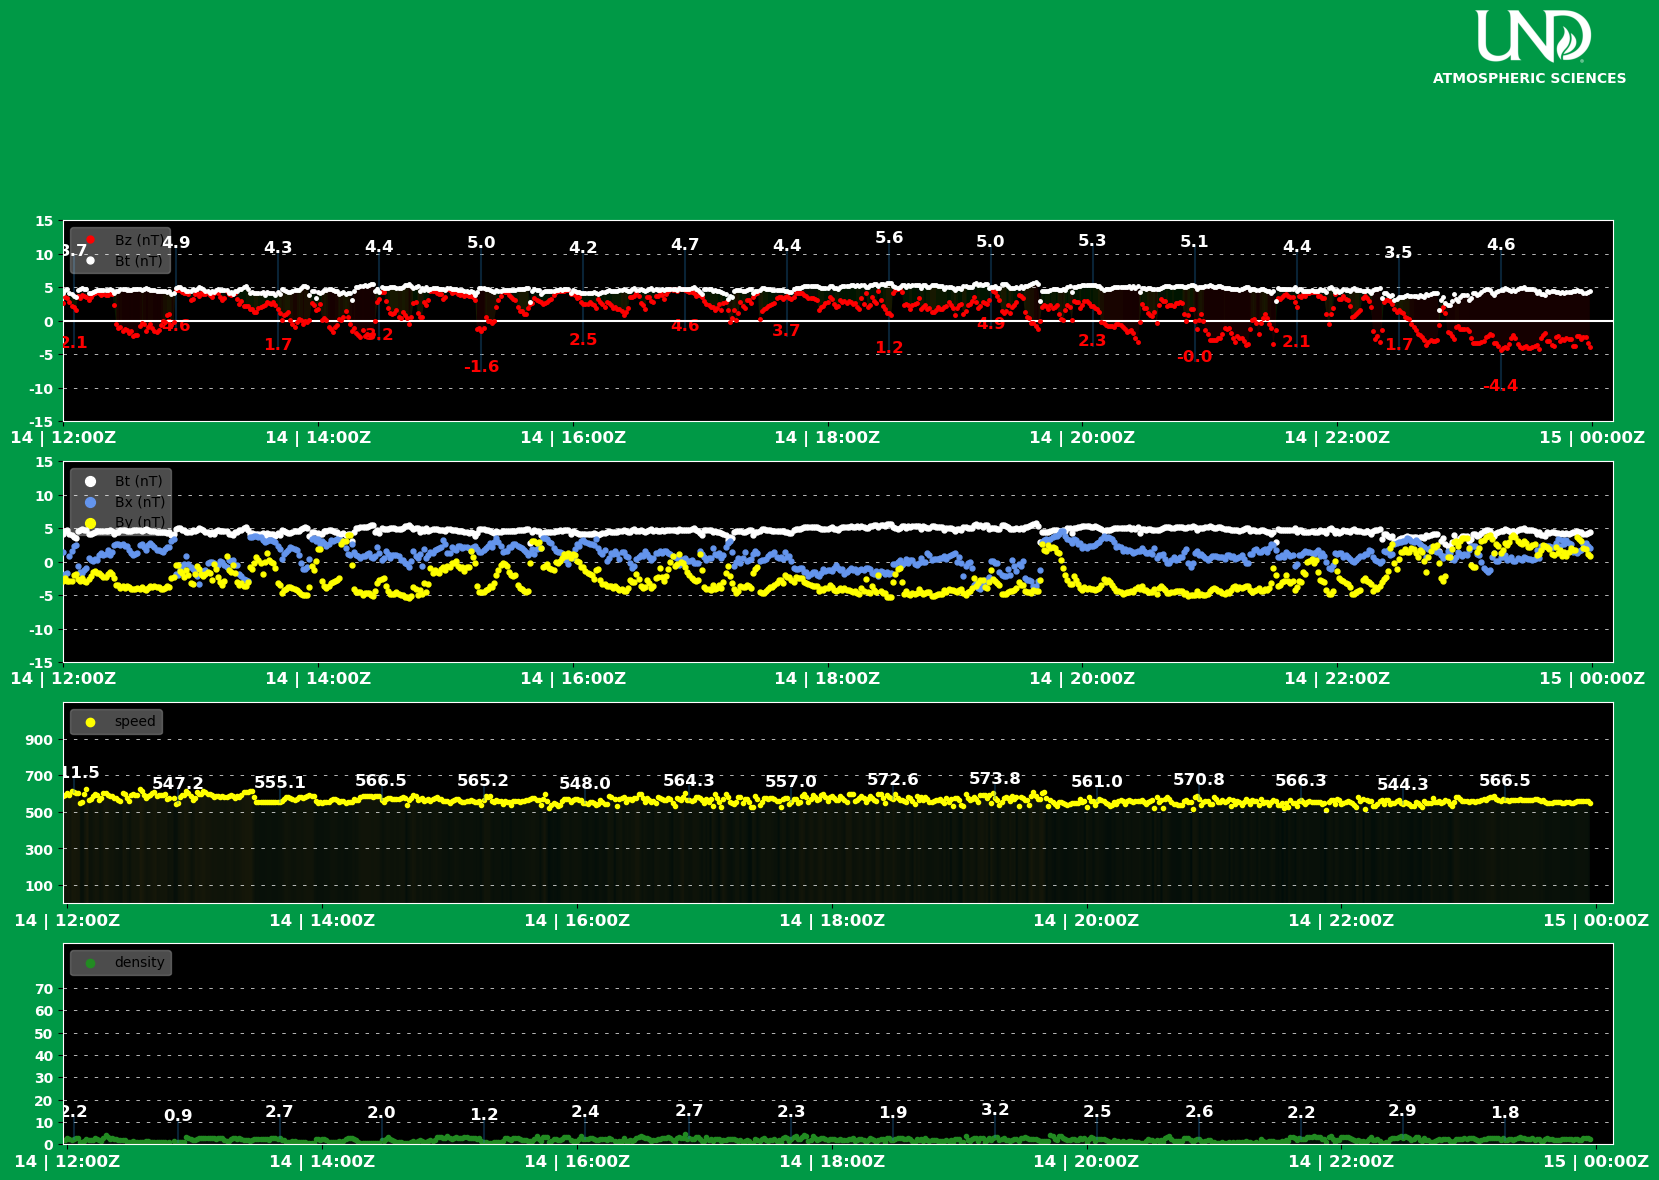

In [9]:
print("############\nSCRIPT RUNNING\n############")
import time as comp_time
st = comp_time.time()

import warnings
warnings.filterwarnings("ignore")

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import numpy as np
import math
from urllib.request import urlopen
from PIL import Image
import sys
import os

# # get script dir
# script_dir = os.path.dirname(os.path.abspath(__file__))

# # get the parent dir 
# project_root = os.path.abspath(os.path.join(script_dir, ".."))

# if project_root not in sys.path:
#     sys.path.append(project_root)
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # add parent dir
from get_data.get_spacewx_data import get_ace_data, get_kp_data

data = get_ace_data()

time_range = 12

### TIME UTILS ###
#####################################################
def time_utils(data, time_range=6, src='magswe'):

    mag_start_date_idx = find_nearest(data['mag_dates'], (data['mag_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    mag_end_date_idx   = -1 
    pam_start_date_idx = find_nearest(data['pam_dates'], (data['pam_dates'][-1] - timedelta(hours=time_range)).replace(second=0, microsecond=0))
    pam_end_date_idx   = -1 

    travel_time = int(((1500000)/(find_latest_vals(data['speed']))/60))
    travel_time_delta = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time)
    travel_time_delta_text = data['pam_dates'][pam_end_date_idx] - timedelta(minutes=travel_time+2)
    
    return [mag_start_date_idx, mag_end_date_idx], [pam_start_date_idx, pam_end_date_idx], [travel_time_delta, travel_time_delta_text]
    



### CHECK FOR VALID DICT KEYS ###
#####################################################
def check_dict_keys(dictionary, keys):
    for key in keys:
        if key not in dictionary:
            raise KeyError(f"INCOMPLETE DATA -- '{key}' data missing -- the data you are trying to plot may not be meant for this plot style, or there is incomplete data")
    

    
    
### REPLACE MISSIN DATA WITH NAN ###
#####################################################    
def replace_missing(array):
    for item in range(0, len(array)):
        if array[item] <= -999.9:
            array[item] = np.nan
    return array


### SIMPLE NAN INTERP FUNCTION ###
#####################################################
def interpolate_nans(array):
    nan_indices = np.isnan(array)
    valid_indices = ~nan_indices
    array[nan_indices] = np.interp(np.flatnonzero(nan_indices), np.flatnonzero(valid_indices), array[valid_indices])
    return array


### FIND IMF Y-LIMIT ###
#####################################################
def find_imf_limit(bt, bz):
    
    bt, bz = replace_missing(bt), replace_missing(bz)  
    max_val = np.nanmax(np.concatenate((abs(bt), abs(bz))))
    nearest_5 = int(math.ceil(max_val / 5.0)) * 5
    
    if (nearest_5 - max_val) <= 3:
        return (nearest_5 + 5) + 5
    else:
        return (nearest_5) + 5
    
     
    
### FIND NEAREST VALUE ###
#####################################################    
def find_nearest(array, value):
        array = np.asarray(array)
        idx = (np.abs(array - value)).argmin()
        return idx
    
    
    
### BUILD SWPC AURORA COLORMAP ###
#####################################################    
def build_aurora_cmap(): 
    from colour import Color
    from matplotlib.colors import LinearSegmentedColormap
    from matplotlib.colors import ListedColormap
    
    color_list = ['#819b7c', '#5ea25c', '#3ba93a', '#01de00', '#6afd00', '#f1ff01', '#ffc900', '#fe8e00', '#fd3300', '#e80001', '#d80000',  '#d80000',  '#d80000',  '#d80000']

    aurora_cmap = ListedColormap([Color(c1).rgb for c1 in color_list ], 'my_list' )
    
    aurora_cmap_r = ListedColormap(aurora_cmap.colors[::-1])
    
    return aurora_cmap, aurora_cmap_r


### COMPUTE CURRENT VALUES ###
#####################################################
def find_latest_vals(data, bz=False):
    
    for item in reversed(data.tolist()):
        if not math.isnan(item):
            latest = item
            break
    # return -9999
    
    if bz == True:
        if latest > 0:
            bz_dir = 'NORTH'
        else:
            bz_dir = 'SOUTH'
        
        return np.round(latest,1), bz_dir
    else:
        return np.round(latest,1)

    
    
### CREATE AURORAL ACTIVITY STR ###
#####################################################
def find_g_level(kp_data):
    
    kp_data = float(kp_data[-1])
    
    g_levels = {
        0:' ', 1:' ', 2:' ', 3:' ', 4:' ',
        5:'| G1', 6:'| G2', 7:'| G3', 8:'| G4', 9:'| G5'
    }

    G = g_levels[int(kp_data)]

    if kp_data <= 3:
        activity = f'Quiet {G}'
    elif kp_data > 3 and a < 5:
        activity = f'Minor {G}'
    elif kp_data >= 5 and a < 7:
        activity = f'Moderate {G}'
    elif kp_data >= 7 and a < 9:
        activity = f'Active {G}'
    elif kp_data >= 9:
        activity = f'Very Active | {G}'
        
    return activity




#############
# BUILD MAG/SWE PLOT #
##################################

# MAKE SOME DATA CORRECTIONS AND TIME LOGIC CALCS
# USE UTIL FUNCTIONS 
mag_idx, pam_idx, travel_time = time_utils(data, time_range)

# get SWPC aurora colormap
aurora_cmap, aurora_cmap_r = build_aurora_cmap()

# build valid-date-string
valid_str = f"VALID: {data['mag_dates'][-1].strftime('%H:%M')}Z - {str.upper(data['mag_dates'][-1].strftime('%h'))} {data['mag_dates'][-1].strftime('%d')} {data['mag_dates'][-1].strftime('%Y')}"

# get KP data and current auroral activity 
kp_data = get_kp_data()
activity_str = find_g_level(kp_data['kp_index'])

# annotation increment 
ann_idx = time_range*4


data['density_intrp'] = interpolate_nans(replace_missing(data['density']))
data['speed_intrp'] = interpolate_nans(replace_missing(data['speed']))
data['bz_intrp'] = interpolate_nans(replace_missing(data['bz']))
data['bt_intrp'] = interpolate_nans(replace_missing(data['bt']))
data['by_intrp'] = interpolate_nans(replace_missing(data['by']))
data['bx_intrp'] = interpolate_nans(replace_missing(data['bx']))

#############
# BUILD FIGURE #
##################################

#=======================================================================================================================#
# DECLARE BASIC FIGURE PROPERTIES 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 12), linewidth=10, edgecolor='#009946')
fig.set_facecolor('#009946')

# DECLARE BASIC SUBPLOT PROPERTIES
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('black')
    ax.tick_params(axis='x', labelsize=12, labelcolor='white')
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    ax.patch.set_alpha(1)
    ax.margins(0)
    ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
    ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
    ax.spines["top"].set_color("white")
    ax.spines["left"].set_color("white")
    ax.spines["right"].set_color("white")
    ax.spines["bottom"].set_color("white")
    ax.spines["bottom"].set_color("white")
    #ax.axvline(x=travel_time[0], color='lightblue', linestyle='--')
#=======================================================================================================================#




#############
# PLOT DATA #
##################################

#=======================================================================================================================#    
# PLOT AXIS 1 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax1.set_ylim(-limit, limit)
ax1.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax1.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax1.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax1.axhline(y=0, color='white', linestyle='-', zorder=9)

# plot data 
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]], 
            'r.', markersize=5, alpha=1, zorder=10, label='Bz (nT)')
ax1.plot(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            'w.', markersize=5, alpha=1, zorder=10, label='Bt (nT)')


# data fill
polygon = ax1.fill_between(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bz_intrp'][mag_idx[0]:mag_idx[1]],  data['bt_intrp'][mag_idx[0]:mag_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts   = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax1.imshow(data['bz_intrp'][mag_idx[0]:mag_idx[1]].reshape(1, -1), cmap=aurora_cmap_r, aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()], label='IMF')
filling.set_clip_path(polygon.get_paths()[0], transform=ax1.transData)


# annotate data
for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bz'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y-6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='red', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y-6], alpha=0.3))

for x, y in zip(data['mag_dates'][mag_idx[0]:mag_idx[1]][5 : : ann_idx], data['bt'][mag_idx[0]:mag_idx[1]].tolist()[5 : : ann_idx]):
    ax1.text(x, y+6, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center', clip_on=True)
    ax1.add_line(matplotlib.lines.Line2D([x, x], [y, y+6], alpha=0.3))
    
leg = ax1.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 2 DATA (MAGNETOMETER)
# use some simple math to find dynamic axis limits 
limit = find_imf_limit(data['bt'][mag_idx[0]:mag_idx[1]], data['bz'][mag_idx[0]:mag_idx[1]])
lbl1, lbl2, lbl3 = int(limit/3), int(limit/3) + int(limit/3), int(limit/3) + int(limit/3) + int(limit/3) 

ax2.set_ylim(-limit, limit)
ax2.set_yticks([-lbl3, -lbl2, -lbl1, 0, lbl1, lbl2, lbl3])
ax2.set_yticklabels([str(-lbl3), str(-lbl2), str(-lbl1), '0', str(lbl1), str(lbl2), str(lbl3)], color='white', weight='bold')
ax2.set_xlim(data['mag_dates'][mag_idx[0]], data['mag_dates'][mag_idx[1]] + timedelta(minutes=10))

ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bt'][mag_idx[0]:mag_idx[1]],
            color='white', marker='.', s=50, alpha=1, zorder=10, label='Bt (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['bx'][mag_idx[0]:mag_idx[1]], 
            color='cornflowerblue', marker='.', s=50, alpha=1, zorder=10, label='Bx (nT)')
ax2.scatter(data['mag_dates'][mag_idx[0]:mag_idx[1]], data['by'][mag_idx[0]:mag_idx[1]],
            color='yellow', marker='.', s=50, alpha=1, zorder=10, label='By (nT)')

ax2.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=======================================================================================================================#




#=======================================================================================================================#
# PLOT AXIS 3 DATA (SOLAR WIND SPEED)
ax3.set_ylim(0, 1100)
ax3.set_yticks([100, 300, 500, 700, 900])
ax3.set_yticklabels(['100', '300', '500', '700', '900'], color='white', weight='bold')
ax3.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax3.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['speed'][pam_idx[0]:pam_idx[1]], 
            marker='.', color='yellow', alpha=1, label ='speed')

# data fill
polygon = ax3.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['speed_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax3.imshow(data['speed_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='summer', aspect='auto', interpolation_stage='data', alpha=0.1,
                    extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax3.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['speed'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax3.text(x, y+80, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax3.add_line(matplotlib.lines.Line2D([x, x], [y, y+80], alpha=0.3))
    
ax3.legend(loc='upper left', framealpha=0.3, markerscale=2)
#======================================================================================================================#




#======================================================================================================================#
# PLOT AXIS 4 DATA (SOLAR WIND DENSITY)
ax4.set_ylim(0, 90)
ax4.set_yticks([0, 10, 20, 30, 40, 50, 60, 70])
ax4.set_yticklabels(['0', '10', '20', '30', '40', '50', '60', '70'], color='white', weight='bold')
ax4.set_xlim(data['pam_dates'][pam_idx[0]], data['pam_dates'][pam_idx[1]] + timedelta(minutes=10))

# plot data 
ax4.scatter(data['pam_dates'][pam_idx[0]:pam_idx[1]], data['density'][pam_idx[0]:pam_idx[1]],
            marker='.', color='forestgreen', alpha=1, label ='density')

# data fill
polygon = ax4.fill_between(data['pam_dates'][pam_idx[0]:pam_idx[1]], 0, data['density_intrp'][pam_idx[0]:pam_idx[1]], interpolate=True, color='none', alpha=0.1, zorder=3)
verts = np.vstack([p.vertices for p in polygon.get_paths()])
filling = ax4.imshow(data['density_intrp'][pam_idx[0]:pam_idx[1]].reshape(1, -1), cmap='Greens', aspect='auto', interpolation_stage='data', alpha=0.1,
                        extent=[verts[:, 0].min(), verts[:, 0].max(), verts[:, 1].min(), verts[:, 1].max()])
filling.set_clip_path(polygon.get_paths()[0], transform=ax4.transData)

# annotate data
for x, y in zip(data['pam_dates'][pam_idx[0]:pam_idx[1]][5 : : ann_idx], data['density'][pam_idx[0]:pam_idx[1]].tolist()[5 : : ann_idx]):
    ax4.text(x, y+10, f"{np.round(y, 1)}", weight='bold', fontsize=12, color='white', alpha=1, ha='center',clip_on=True)
    ax4.add_line(matplotlib.lines.Line2D([x, x], [y, y+10], alpha=0.3))
    
ax4.legend(loc='upper left', framealpha=0.3, markerscale=2)
#=====================================================================================================================#




# ### ALL PLOT TITLES ###
# ######################################
# plt.figtext(0.10, 1, f"{str.upper(data['meta']['sat-name'])} | 1MIN MAGNETOMETER & SWEPAM", 
#             ha='left', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 1,  f"IMF (nT) | Bt: {find_latest_vals(data['bt_intrp'])}, Bz: {find_latest_vals(data['bz_intrp'])} {find_latest_vals(data['bz_intrp'], bz=True)[1]}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.75,  f"IMF STRENGTH & FLUX ROPE CONFIGURATIONS (nT) | Bt, Bx, By   ",
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.50,  f"SOLAR WIND SPEED (km/s) | CURRENT: {find_latest_vals(data['speed_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.98, 0.252, f"SOLAR WIND DENSITY (cm^-3) | CURRENT: {find_latest_vals(data['density_intrp'])}   ", 
#             ha='right', weight='bold', fontsize=18, color='yellow')
# plt.figtext(0.10, 1.045, f"AURORAL ACTIVITY SUMMARY", 
#             ha='left', weight='bold', fontsize=27, color='white')
# plt.figtext(0.10, 1.025, valid_str, 
#             ha='left', weight='bold', fontsize=17, color='white')
# plt.figtext(0.98, 1.03,  f"ACTIVITY: {str.upper(activity_str)}", 
#             ha='right', weight='bold', fontsize=20, color='white')
# plt.figtext(0.03, -0.01, f"'STEVEPY' SPACE WEATHER DATA ANALYSIS TOOL |", 
#             weight='bold', color='yellow', fontsize=12, ha='left', alpha=0.6)
# plt.figtext(0.268, -0.01, f"  (C) KYLE J GILLETT 2024, CENTRAL MICHIGAN UNIVERSITY | BETA VERSION, AVAILABLE SOON", 
#             weight='bold', color='yellow', fontsize=9, ha='left', alpha=0.6)

# plt.figtext(-0.01, 1.07, ' ')
# plt.figtext(1, -0.02, ' ')

img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')



print("    FINISHED ACE FIGURE")

    
#############################################################################################################################################################################
#############################################################################################################################################################################
#############################################################################################################################################################################



elapsed_time = comp_time.time() - st
print(f"############\nSCRIPT FINISHED: time: {comp_time.strftime("%H:%M:%S", comp_time.gmtime(elapsed_time))}\n############")

(np.float64(-0.5), np.float64(929.5), np.float64(424.5), np.float64(-0.5))

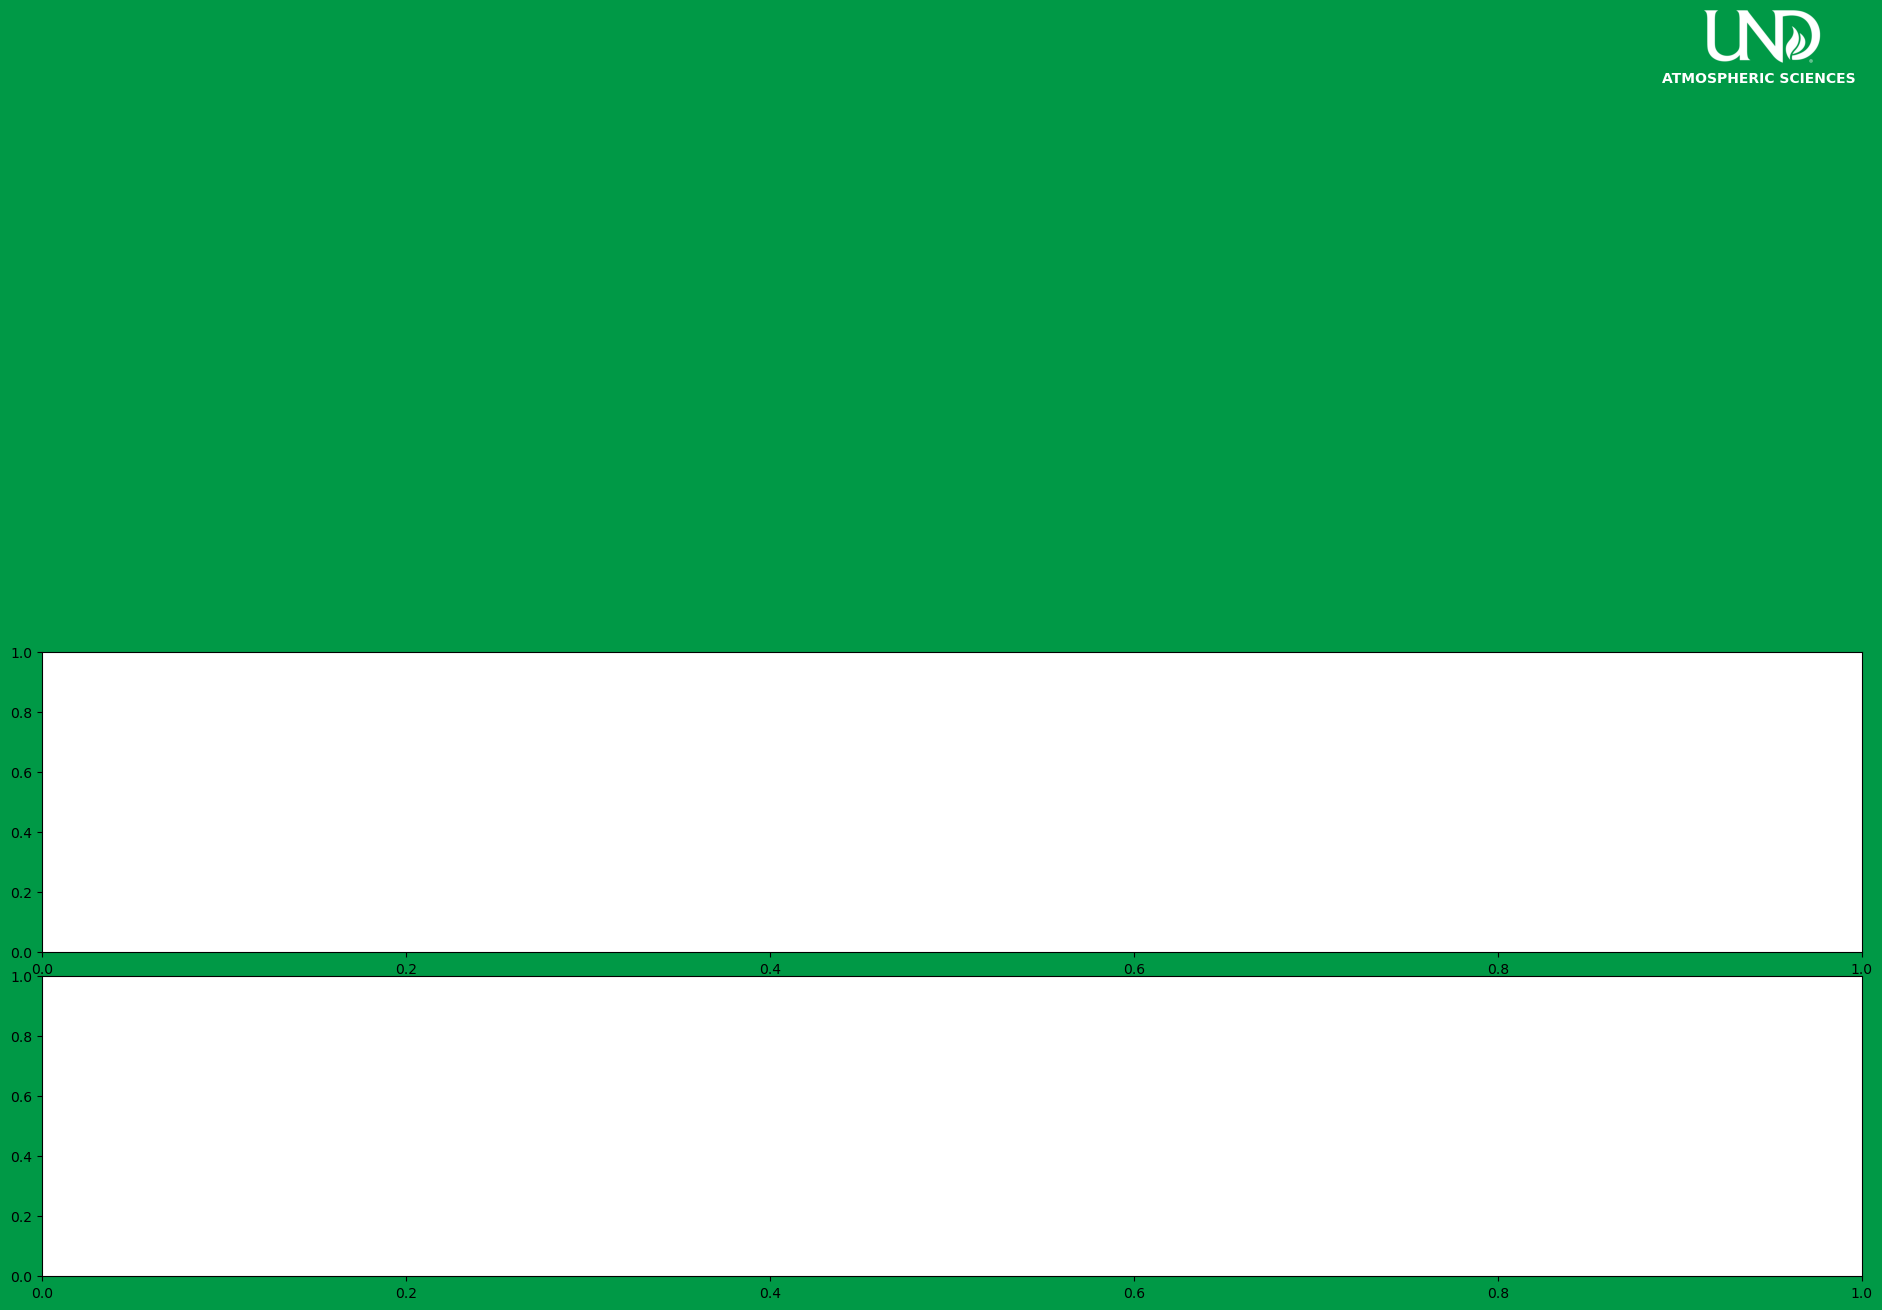

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.set_facecolor('#009946')

ax1 = plt.axes([0, 0, 0.91, 0.25])
ax2 = plt.axes([0, 0.27, 0.91, 0.25])
ax3 = plt.axes([0, 0.27, 0.91, 0.25])
ax4 = plt.axes([0, 0.27, 0.91, 0.25])

# for ax in [ax1, ax2, ax3, ax4]:
#     ax.set_facecolor('black')
#     ax.tick_params(axis='x', labelsize=12, labelcolor='white')
#     for label in ax.get_xticklabels():
#         label.set_fontweight('bold')
#     ax.patch.set_alpha(1)
#     ax.margins(0)
#     ax.xaxis.set_major_formatter((mdates.DateFormatter('%d'+' | '+'%H:%M'+'Z')))
#     ax.grid(which='major', axis='y', linestyle=(0, (5, 10)), color='white', linewidth=0.5)
#     ax.spines["top"].set_color("white")
#     ax.spines["left"].set_color("white")
#     ax.spines["right"].set_color("white")
#     ax.spines["bottom"].set_color("white")
#     ax.spines["bottom"].set_color("white")


img = Image.open('../utils/images/und-logo.png')
#                  side-side  up-down  size   size
imgax = fig.add_axes([0.83, 1.01, 0.06, 0.06], anchor='SE', zorder=3)
plt.figtext(0.81, 0.995, f'ATMOSPHERIC SCIENCES', ha='left', weight='bold', fontsize=10, color='white')
imgax.imshow(img)
imgax.axis('off')
